# Tree-DTW playground — the **networkx rebuild** (`tree_dtw_nx`)

Interactive tests + visualization for the rebuilt matcher in `network_matching.tree_dtw_nx` (docs `docs/tree_dtw_nx.md`). A source **tree** `A` and target **network** `B` are plain `networkx.DiGraph`s (nodes carry `x, y`); the matcher runs the six parts — candidates → emission `E` → forward `D` → backward `B` → extraction → validation.

**Why this notebook and not `tree_dtw_playground.ipynb`.** That one drives the *old* `tree_dtw.match_tree_to_bgraph`, whose **segment validation collapses the arc match to a point matching** and so prints phantom `V1` crosses (docs §8.1/§8.7). The rebuild validates on the graph it matches on — `A`/`B` for point mode, `L(A)`/`L(B)` for segment mode — and never collapses. It also adds the §6b **cross-table reciprocity** check (forward and backward tables must agree on the one optimum).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import importlib
import matplotlib.pyplot as plt
import network_matching.tree_dtw_nx as tnx
importlib.reload(tnx)

# built-in synthetic scenarios: source tree A, target network B (both nx.DiGraph, nodes carry x, y)
def cases():
    return {
        "chain":   (tnx.digraph({0:(0,0),1:(10,0),2:(20,0)}, [(0,1),(1,2)]),
                    tnx.digraph({"b0":(0,.5),"b1":(10,.5),"b2":(20,.5)}, [("b0","b1"),("b1","b2")])),
        "y_split": (tnx.digraph({0:(0,0),1:(10,0),2:(20,6),3:(20,-6)}, [(0,1),(1,2),(1,3)]),
                    tnx.digraph({"s":(0,.5),"j":(10,.5),"u":(20,6.5),"d":(20,-5.5)}, [("s","j"),("j","u"),("j","d")])),
        "merge":   (tnx.digraph({0:(0,6),1:(0,-6),2:(10,0),3:(20,0)}, [(0,2),(1,2),(2,3)]),
                    tnx.digraph({"a":(0,6.5),"b":(0,-5.5),"m":(10,.5),"o":(20,.5)}, [("a","m"),("b","m"),("m","o")])),
    }

def _xy(G, n):    return (G.nodes[n]["x"], G.nodes[n]["y"])
def _edges_xy(G): return [(_xy(G,u), _xy(G,v)) for u,v in G.edges]

def draw(bgA, bgB, connectors, ax, title):
    """Grey = target B, black = source A, dashed orange = the matched pairs (pivot -> committed cell)."""
    for p,q in _edges_xy(bgB):
        ax.plot([p[0],q[0]],[p[1],q[1]], color="0.78", lw=6, solid_capstyle="round", zorder=1)
    for p,q in _edges_xy(bgA):
        ax.plot([p[0],q[0]],[p[1],q[1]], color="k", lw=1.8, zorder=3)
    for s,t in connectors:
        ax.plot([s[0],t[0]],[s[1],t[1]], color="C1", lw=1.1, ls="--", zorder=2)
        ax.scatter([s[0]],[s[1]], s=16, color="k", zorder=4)
    ax.set_title(title, fontsize=10); ax.set_aspect("equal"); ax.margins(0.18); ax.set_xticks([]); ax.set_yticks([])

def run_point(A, B, r=20.0, alpha=1.0, beta=1.0):
    tnx.prepare(A, B, r=r); tnx.forward(A, B, alpha=alpha, beta=beta); tnx.backward(A, B, alpha=alpha, beta=beta)
    return tnx.extract(A, B)

## 1. The pipeline — point mode

`prepare → forward → backward → extract`, then three independent checks: `check_rules` (V1–V4 on the matching), `validate_tables` (every `D`/`B` cell is a legal warping in isolation), and `check_reciprocity` (the two tables agree on the one optimum, §6b).

matching M (source vertex -> target vertex):
   0 -> s
   1 -> j
   2 -> u
   3 -> d
validity V1..V4     : VALID
per-cell tables     : D 12 cells ok;  B 12 cells ok
cross-table (§6b)   : AGREE


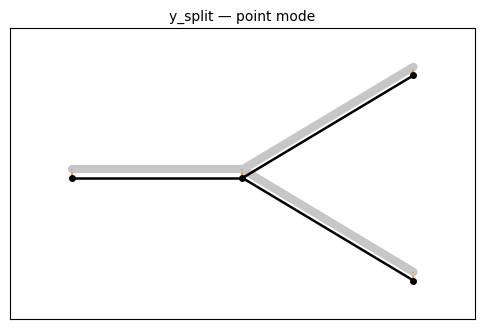

In [2]:
A, B = cases()["y_split"]
M, committed = run_point(A, B)
print("matching M (source vertex -> target vertex):")
for a in sorted(A.nodes, key=str): print(f"   {a} -> {committed[a]}")
v1,v2,v3 = tnx.check_rules(M, A, B)
v4 = [a for a in A.nodes if not any(x==a for (x,_w) in M)]
print("validity V1..V4     :", "VALID" if not (v1 or v2 or v3 or v4) else (v1,v2,v3,v4))
nD,badD = tnx.validate_tables(A,B,"D"); nB,badB = tnx.validate_tables(A,B,"B")
print(f"per-cell tables     : D {nD} cells {'ok' if not badD else 'BAD'};  B {nB} cells {'ok' if not badB else 'BAD'}")
print("cross-table (§6b)   :", "AGREE" if not tnx.check_reciprocity(A, committed) else tnx.check_reciprocity(A, committed))

fig, ax = plt.subplots(figsize=(6,4))
draw(A, B, [(_xy(A,a), _xy(B,committed[a])) for a in A.nodes], ax, "y_split — point mode")
plt.show()

## 2. The three scenarios (point mode)

`chain` (classic DTW), `y_split` (one branch), `merge` (two branches join). Each is valid and the tables agree.

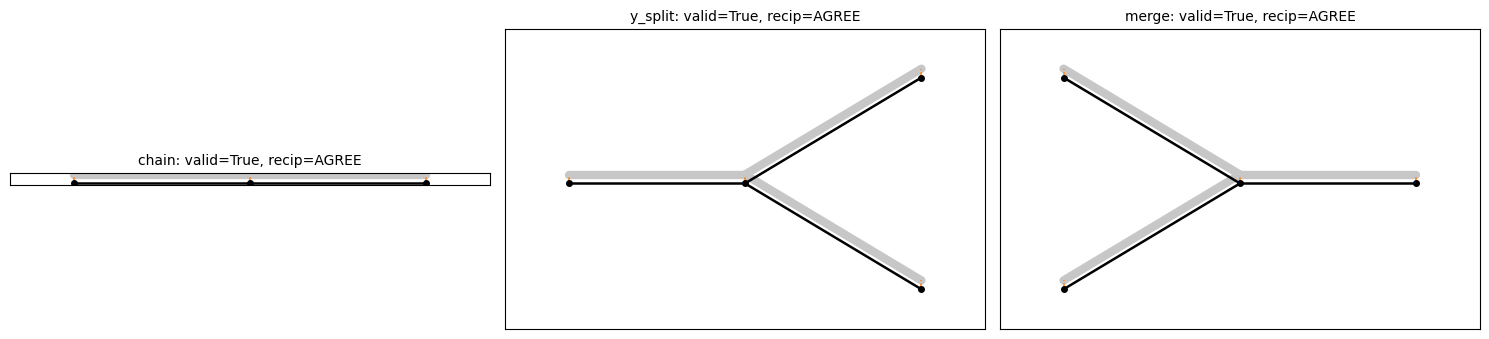

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, name in zip(axes, ["chain","y_split","merge"]):
    A,B = cases()[name]
    M, committed = run_point(A,B)
    r = tnx.check_rules(M,A,B); valid = not (r[0] or r[1] or r[2])
    recip = "AGREE" if not tnx.check_reciprocity(A,committed) else "FAIL"
    draw(A,B, [(_xy(A,a),_xy(B,committed[a])) for a in A.nodes], ax, f"{name}: valid={valid}, recip={recip}")
fig.tight_layout(); plt.show()

## 3. Segment mode — the line-graph `L(A)`/`L(B)`

`emission="segment"` is the same six parts on `line_digraph(A)` vs `line_digraph(B)`: each node is an **arc** (`x, y` = midpoint, plus a `bearing`), `E` = midpoint distance + `bearing_weight · circ(bearing)`. The match is arc→arc and is **validated on the line-graph** — no point collapse, so no phantom crosses.

segment matching (source arc -> target arc):
   (0, 1) -> ('s', 'j')
   (1, 2) -> ('j', 'u')
   (1, 3) -> ('j', 'd')
validity on L(A)/L(B): VALID
cross-table (§6b)    : AGREE


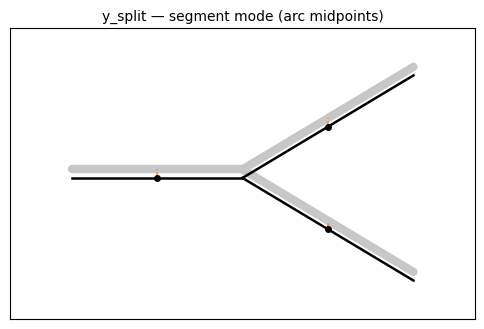

In [4]:
A, B = cases()["y_split"]
LA, LB = tnx.line_digraph(A), tnx.line_digraph(B)
tnx.prepare(LA, LB, r=20.0, bearing_weight=2.0); tnx.forward(LA, LB); tnx.backward(LA, LB)
Mseg, committed = tnx.extract(LA, LB)
print("segment matching (source arc -> target arc):")
for s in sorted(LA.nodes, key=str): print(f"   {s} -> {committed[s]}")
v1,v2,v3 = tnx.check_rules(Mseg, LA, LB)
print("validity on L(A)/L(B):", "VALID" if not (v1 or v2 or v3) else (v1,v2,v3))
print("cross-table (§6b)    :", "AGREE" if not tnx.check_reciprocity(LA, committed) else "FAIL")

fig, ax = plt.subplots(figsize=(6,4))
draw(A, B, [(_xy(LA,s), _xy(LB,committed[s])) for s in LA.nodes], ax, "y_split — segment mode (arc midpoints)")
plt.show()

## 4. Cross-table agreement — the §6b reciprocity check

`validate_tables` checks each `D`/`B` cell in isolation; `check_reciprocity` checks the two tables **agree** — every source edge the forward back-pointers thread, the backward ones thread back:

$$(p,\ \mathrm{tail}(p)) \in \mathrm{bpD}[c][\mathrm{head}(c)] \iff (c,\ \mathrm{head}(c)) \in \mathrm{bpB}[p][\mathrm{tail}(p)]$$

It **AGREE**s on the split; then one deliberately severed backward pointer is **caught**. (It holds only on the committed matching — off the optimum `D` and `B` optimise differently-pinned subproblems, docs §6b.)

In [5]:
A, B = cases()["y_split"]
M, committed = run_point(A, B)
print("reciprocity      :", "AGREE" if not tnx.check_reciprocity(A, committed) else "FAIL")

# sever ONE backward pointer at the split (vertex 1 -> successor 2); the check must catch it
t = tnx._advance_anchor(A, 1, committed[1], "bpB")
print(f"bpB[1][{t}] before:", A.nodes[1]["cand"][t]["bpB"])
A.nodes[1]["cand"][t]["bpB"] = [(s,w) for (s,w) in A.nodes[1]["cand"][t]["bpB"] if s != 2]
print(f"bpB[1][{t}] after :", A.nodes[1]["cand"][t]["bpB"], "  (severed the 1->2 continuation)")
print("reciprocity now  :", tnx.check_reciprocity(A, committed) or "AGREE")

reciprocity      : AGREE
bpB[1][j] before: [(2, 'u'), (3, 'd')]
bpB[1][j] after : [(3, 'd')]   (severed the 1->2 continuation)
reciprocity now  : [(1, 2, 'forward 1->2 unmirrored: (2,u) not in bpB[1][j]')]
